# Proyecto 1: EDA Honesto, Feature Engineering y Baseline k-NN

**Ciencia de Datos, Sección A** · Segundo Semestre 2026  
**Autor:** Josué Aguilar  
**Dataset elegido:** Censo completo del RMS Titanic (`titanic5.xlsx - Titanic5_all.csv`)  
**Archivo final:** `P1-Aguilar.ipynb`  

---

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

El naufragio del RMS Titanic en abril de 1912 constituye uno de los eventos marítimos y sociológicos más documentados de la historia moderna. Tradicionalmente, los análisis predictivos sobre este desastre se han restringido a subconjuntos de pasajeros civiles, omitiendo el papel determinante de la tripulación técnica y de servicio, o asumiendo homogeneidad en los protocolos de salvamento. Sin embargo, la evacuación estuvo regida por tensiones estructurales: la directiva marítima de "mujeres y niños primero", la proximidad física a la cubierta superior según la tarifa abonada y la asignación laboral de emergencia de los miembros de la tripulación.

Este análisis busca responder: ¿con qué grado de certeza es posible estimar la probabilidad de supervivencia de un tripulante o pasajero del Titanic utilizando únicamente atributos demográficos, puerto de embarque, estructura familiar y rol funcional a bordo (`Class/Dept`), y en qué medida este modelo refleja la disparidad en la ejecución del protocolo de evacuación entre las distintas clases sociales y departamentos operativos?

Esta respuesta resulta de alto valor para historiadores cuantitativos, sociólogos de catástrofes y analistas de gestión de riesgos y seguridad humana. Permite determinar con rigor empírico si los patrones de supervivencia obedecieron primariamente a normas de caballería socialmente prescritas, a jerarquías socioeconómicas institucionalizadas o al rol logístico asignado durante la emergencia. Si la evidencia demostrara que el rol operativo y la clase social condicionaron la supervivencia por encima de los factores demográficos universales, se confirmaría que las emergencias no anulan las desigualdades preexistentes, sino que las exacerban bajo la apariencia de protocolos neutrales.

**Pregunta central:** ¿Con qué grado de certeza es posible estimar la probabilidad de supervivencia de un tripulante o pasajero del Titanic utilizando únicamente atributos demográficos, puerto de embarque, estructura familiar y rol funcional a bordo (`Class/Dept`), y en qué medida este modelo refleja la disparidad en la ejecución del protocolo de evacuación entre las distintas clases sociales y departamentos operativos?

**Tipo de problema:** Clasificación binaria supervisada.

**Variable objetivo:** `Survived` (0 = No sobrevivió / Fallecido, 1 = Sobrevivió).

## 2. Los datos

- **Fuente:** Registros censales compilados de la *Encyclopedia Titanica* en conjunción con los manifiestos oficiales de embarque de los puertos de Southampton, Cherbourg, Queenstown y Belfast.
- **Archivo analizado:** `titanic5.xlsx - Titanic5_all.csv`.
- **Fecha de descarga:** Septiembre de 2026.
- **Licencia y términos de uso:** Acceso público con fines de docencia, investigación histórica y análisis académico sin fines comerciales.
- **Unidad de observación:** Cada registro individual representa a una persona única que se encontraba formalmente a bordo del RMS Titanic al momento del siniestro (total: 2,208 registros censales completos entre pasajeros de todas las clases y personal de todas las áreas de servicio y oficiales).

### Diccionario preliminar de variables

| Variable | Tipo conceptual | Descripción |
|---|---|---|
| `Name_ID` | Identificador | Clave numérica única de la persona en el registro |
| `Name`, `First`, `Last` | Texto | Nombre completo y apellidos del individuo |
| `Sex`, `Female`, `Male` | Categórica / Binaria | Sexo biológico reportado en el manifiesto |
| `Age`, `Age_F`, `Age_F_Code` | Numérica / Texto | Edad registrada en años y códigos de aproximación |
| `Class/Dept` | Categórica | Rol funcional a bordo (1st, 2nd, 3rd Class, Deck Crew, Engineering Crew, Victualling Crew, Restaurant Staff, Band) |
| `Class` | Categórica / Numérica | Indicador simplificado de clase de pasaje |
| `Ticket` | Alfanumérico | Número de boleto comercial (disponible en pasaje civil) |
| `Price` | Numérico / Texto | Tarifa pagada expresada en formato de libras esterlinas históricas |
| `Joined` | Categórica | Puerto donde abordó el barco (Southampton, Cherbourg, Queenstown, Belfast) |
| `Job`, `Occupation` | Texto | Ocupación laboral o función específica reportada |
| `DoB`, `DoB_Clean`, `Year_Birth` | Fecha / Numérica | Fecha y año de nacimiento |
| `Date_Death` | Fecha | Fecha de fallecimiento registrada |
| `Boat [Body]` | Alfanumérico | Identificador del bote salvavidas de rescate o número de cuerpo recuperado |
| `URL` | Texto | Enlace a la ficha biográfica de Encyclopedia Titanica |
| `sibsp` | Numérica entera | Número de cónyuges, hermanos y hermanas a bordo |
| `parch` | Numérica entera | Número de padres e hijos a bordo |
| `Survived` | Binaria (Target) | Supervivencia al desastre (1 = Sobrevivió, 0 = Falleció) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fijar semilla para reproducibilidad
RANDOM_STATE = 42

# Configuracion estetica para graficas legibles
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
sns.set_theme(style='whitegrid')

# Cargar el dataset censal completo
dataset_path = 'titanic5.xlsx - Titanic5_all.csv'
df = pd.read_csv(dataset_path)

print(f'Dataset cargado exitosamente: {dataset_path}')
print(f'Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas')

Dataset cargado exitosamente: titanic5.xlsx - Titanic5_all.csv
Dimensiones iniciales: 2208 filas y 27 columnas


## 3. Primer barrido

A continuación se realiza una inspección inicial de las dimensiones, tipos de datos, primeros registros y conteos de valores ausentes para obtener un diagnóstico preliminar del censo.

In [2]:
# Inspeccion general: dimensiones, vista inicial y recuento de nulos
print('--- FORMA DEL CONJUNTO DE DATOS ---')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n')

print('--- PRIMERAS CINCO FILAS ---')
display(df.head())

print('\n--- INFORMACION GENERAL DE TIPOS (df.info) ---')
df.info()

print('\n--- RECUENTO DE VALORES NULOS POR VARIABLE ---')
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_summary = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percent.round(2)
})
display(null_summary[null_summary['Valores Nulos'] > 0])

--- FORMA DEL CONJUNTO DE DATOS ---
Filas: 2208, Columnas: 27

--- PRIMERAS CINCO FILAS ---


,Name_ID,Name,Female,Male,Sex,Age,Class/Dept,Class,Ticket,Joined,...,Title,First,DoB,Year_Birth,Date_Death,DoB_Clean,Age_F_Code,Age_F,sibsp,parch
0,531,"DEAN, Miss Elizabeth Gladys 'Millvina'",1,0,female,0.17,3rd Class Passenger,3,2315,Southampton,...,Miss,Elizabeth Gladys 'Millvina',2/2/1912,NaN,5/31/2009,2/2/1912,C,0.2,1.0,2.0
1,498,"DANBOM, Master Gilbert Sigvard Emanuel",0,1,male,0.33,3rd Class Passenger,3,347080,Southampton,...,Master,Gilbert Sigvard Emanuel,11/16/1911,NaN,4/15/1912,11/16/1911,C,0.0,0.0,2.0
2,1961,"TANNuS, Master As'ad",0,1,male,0.42,3rd Class Passenger,3,2625,Cherbourg,...,Master,As'ad,11/8/1911,NaN,6/12/1931,11/8/1911,C,0.0,0.0,1.0
3,811,"HäMäLäINEN, Master Viljo Unto Johannes",0,1,male,0.58,2nd Class Passenger,2,250649,Southampton,...,Master,Viljo Unto Johannes,8/29/1911,NaN,,8/29/1911,C,1.0,1.0,1.0
4,1551,"PEACOCK, Master Albert Edward",0,1,male,0.58,3rd Class Passenger,3,3101315,Southampton,...,Master,Albert Edward,9/8/1911,NaN,4/15/1912,9/8/1911,C,1.0,1.0,1.0



--- INFORMACION GENERAL DE TIPOS (df.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name_ID      2208 non-null   int64  
 1   Name         2208 non-null   str    
 2   Female       2208 non-null   int64  
 3   Male         2208 non-null   int64  
 4   Sex          2208 non-null   str    
 5   Age          2154 non-null   float64
 6   Class/Dept   2208 non-null   str    
 7   Class        2208 non-null   str    
 8   Ticket       1317 non-null   str    
 9   Joined       2208 non-null   str    
 10  Occupation   1587 non-null   str    
 11  Boat [Body]  2208 non-null   str    
 12  Price        2208 non-null   str    
 13  Job          958 non-null    str    
 14  Survived     2208 non-null   int64  
 15  URL          2208 non-null   str    
 16  Last         2208 non-null   str    
 17  Title        2208 non-null   str    
 18  First      

,Valores Nulos,Porcentaje (%)
Age,54,2.45
Ticket,891,40.35
Occupation,621,28.12
Job,1250,56.61
DoB,977,44.25
Year_Birth,1587,71.88
DoB_Clean,355,16.08
Age_F,2,0.09
sibsp,899,40.72
parch,899,40.72


In [3]:
# Resumen descriptivo de numericas y tablas de frecuencias de variables categoricas clave
print('--- ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS ---')
display(df.describe().T)

print('\n--- DISTRIBUCION DE FRECUENCIAS: VARIABLE OBJETIVO (Survived) ---')
display(df['Survived'].value_counts().to_frame(name='Conteo').assign(
    Proporcion=df['Survived'].value_counts(normalize=True).round(4)
))

print('\n--- DISTRIBUCION DE FRECUENCIAS: ROL FUNCIONAL (Class/Dept) ---')
display(df['Class/Dept'].value_counts().to_frame(name='Conteo').assign(
    Proporcion=df['Class/Dept'].value_counts(normalize=True).round(4)
))

print('\n--- DISTRIBUCION DE FRECUENCIAS: PUERTO DE EMBARQUE (Joined) ---')
display(df['Joined'].value_counts(dropna=False).to_frame(name='Conteo').assign(
    Proporcion=df['Joined'].value_counts(normalize=True, dropna=False).round(4)
))

--- ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS ---


,count,mean,std,min,25%,50%,75%,max
Name_ID,2208.0,1104.500000,637.539018,1.00,552.75,1104.5,1656.25,2208.0
Female,2208.0,0.221467,0.415328,0.00,0.00,0.0,0.00,1.0
Male,2208.0,0.778533,0.415328,0.00,1.00,1.0,1.00,1.0
Age,2154.0,30.158770,11.958248,0.17,22.00,29.0,37.00,71.0
Survived,2208.0,0.322464,0.467525,0.00,0.00,0.0,1.00,1.0
Age_F,2206.0,30.146963,12.114540,0.00,22.00,29.0,38.00,74.0
sibsp,1309.0,0.498854,1.041658,0.00,0.00,0.0,1.00,8.0
parch,1309.0,0.385027,0.865560,0.00,0.00,0.0,0.00,9.0



--- DISTRIBUCION DE FRECUENCIAS: VARIABLE OBJETIVO (Survived) ---


,Conteo,Proporcion
Survived,,
0,1496,0.6775
1,712,0.3225



--- DISTRIBUCION DE FRECUENCIAS: ROL FUNCIONAL (Class/Dept) ---


,Conteo,Proporcion
Class/Dept,,
3rd Class Passenger,709,0.3211
Victualling Crew,431,0.1952
Engineering Crew,325,0.1472
1st Class Passenger,324,0.1467
2nd Class Passenger,276,0.1250
Restaurant Staff,69,0.0312
Deck Crew,66,0.0299
Band,8,0.0036



--- DISTRIBUCION DE FRECUENCIAS: PUERTO DE EMBARQUE (Joined) ---


,Conteo,Proporcion
Joined,,
Southampton,1614,0.7310
Cherbourg,272,0.1232
Belfast,199,0.0901
Queenstown,123,0.0557


**Observaciones del primer barrido:**

1. **Magnitud censal y desbalance del target:** El dataset contiene exactamente 2,208 registros, lo cual representa el censo exhaustivo de personas a bordo (no solo una muestra civil). La tasa general de supervivencia es del 32.25% (712 sobrevivientes) frente al 67.75% de mortalidad (1,496 fallecidos). Este desbalance exige que cualquier partición de validación sea estrictamente estratificada y que el modelo evaluador supere métricas más exigentes que el accuracy bruto.
2. **Estructura jerárquica y operativa (`Class/Dept`):** A diferencia de los datasets estándar del Titanic que solo contemplan 1ª, 2ª y 3ª clase, este censo incorpora departamentos funcionales de tripulación: personal de aprovisionamiento (`Victualling Crew`: 431 personas, 19.52%), maquinistas y fogoneros (`Engineering Crew`: 325 personas, 14.72%), personal de cubierta (`Deck Crew`: 66 personas, 2.99%), restaurante a la carta (`Restaurant Staff`: 69 personas, 3.13%) y la banda de música (`Band`: 8 personas). La 3ª clase es el grupo civil mayoritario con 709 pasajeros (32.11%).
3. **Presencia de variables post-evento y calidad de registros familiares:** Se detecta la presencia de columnas como `Boat [Body]`, `Date_Death` y `URL`. Estas columnas contienen información retrospectiva directa del desenlace (fuga de target o *data leakage*). Asimismo, variables demográficas como `sibsp` y `parch` exhiben 899 valores ausentes que coinciden exactamente con la tripulación, lo que indica un mecanismo sistemático condicionado al rol (MAR) que no debe descartarse con `dropna()`, sino imputarse coherentemente.

## 4. Calidad de datos

En esta etapa se abordan tres aspectos metodológicos fundamentales:
1. **Prevención rigurosa de Data Leakage (Fuga de datos):** La identificación y descarte de variables retrospectivas post-evento.
2. **Depuración de identificadores y redundancias:** Eliminación de variables de texto libre, identificadores artificiales y atributos duplicados que introducen ruido dimensional.
3. **Diagnóstico formal de valores ausentes (Mecanismos MCAR/MAR/MNAR) y análisis de outliers:** Evaluación del comportamiento de nulos y verificación de valores extremos reales frente a posibles errores de captura.

### 4.1 Prevención de Data Leakage y depuración de variables

En problemas predictivos del mundo real, el *data leakage* ocurre cuando información posterior al desenlace o información directa de la etiqueta objetivo se filtra a la matriz de diseño $X$. En este censo, detectamos tres fuentes críticas de fuga:
- `Boat [Body]`: Indica el bote salvavidas en el que fue rescatada la persona o el identificador del cuerpo recuperado del océano por buques como el CS Mackay-Bennett. Conocer el bote implica supervivencia garantizada ($100\%$); conocer el código del cuerpo implica fallecimiento certero ($0\%$). Esta información solo existió *ex-post* y no estaba disponible en el momento en que zarpó el barco.
- `Date_Death`: Registrar la fecha del naufragio (15 de abril de 1912) etiqueta inequívocamente al individuo como víctima mortal, filtrando directamente la variable objetivo.
- `URL`: Los hipervínculos biográficos contienen literales explícitos como `/titanic-victim/` o `/titanic-survivor/`, lo cual constituye una fuga trivial del target.

Asimismo, se descartan variables de identificación unívoca o de alta dispersión sin valor predictivo generalizable:
- `Name_ID`, `Name`, `First`, `Last`: Identificadores nominales directos.
- `DoB`, `DoB_Clean`, `Year_Birth`, `Age_F_Code`, `Age_F`: Redundantes con la variable continua `Age`.
- `Class`: Indicador civil simplificado que es redundante y menos informativo que `Class/Dept` (el cual incluye a la tripulación).
- `Job`, `Occupation`: Textos libres dispersos e incompletos.
- `Price`: Formato monetario histórico no estandarizado en libras (£, s, d) y ausente para la totalidad de la tripulación.
- `Ticket`: Código de pasaje civil no aplicable al personal técnico.
- `Female`, `Male`: Binarizaciones redundantes de la variable `Sex`.

In [4]:
# Eliminacion de variables con Data Leakage e identificadores redundantes
cols_leakage = ['Boat [Body]', 'Date_Death', 'URL']
cols_redundant = [
    'Name_ID', 'Name', 'First', 'Last', 'DoB', 'DoB_Clean', 'Year_Birth',
    'Age_F_Code', 'Age_F', 'Class', 'Job', 'Price', 'Occupation',
    'Ticket', 'Female', 'Male'
]

print(f'Variables de Data Leakage a descartar: {cols_leakage}')
print(f'Variables redundantes/identificadores a descartar: {len(cols_redundant)} columnas')

df = df.drop(columns=cols_leakage + cols_redundant).copy()

print(f'\nDimensiones tras depuracion: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'Columnas retenidas para el estudio: {list(df.columns)}')

Variables de Data Leakage a descartar: ['Boat [Body]', 'Date_Death', 'URL']
Variables redundantes/identificadores a descartar: 16 columnas

Dimensiones tras depuracion: 2208 filas y 8 columnas
Columnas retenidas para el estudio: ['Sex', 'Age', 'Class/Dept', 'Joined', 'Survived', 'Title', 'sibsp', 'parch']


### 4.2 Diagnóstico formal de valores ausentes (Mecanismos)

Examinamos la naturaleza de las variables con valores faltantes en el conjunto depurado:
- `sibsp` y `parch` (899 valores ausentes, $40.72\%$): El recuento de nulos coincide exactamente con la cantidad total de miembros de la tripulación ($899$ tripulantes). Esto demuestra un mecanismo **MAR (Missing at Random)** estrictamente condicionado por la pertenencia a la tripulación (`Class/Dept`). La administración de la White Star Line no emitía boletos comerciales con registro de parentesco para sus empleados marítimos; estos viajaban en calidad de trabajadores individuales. Por ende, la imputación fundamentada es asignar el valor numérico `0` (viajaban sin núcleo familiar a bordo). Un `dropna()` aquí destruiría arbitrariamente al $100\%$ de la tripulación, sesgando el estudio.
- `Age` (54 valores ausentes, $2.45\%$): Los datos faltantes corresponden tanto a pasajeros como a tripulantes de diversa índole, constituyendo un mecanismo **MAR/MCAR**. Al representar una fracción menor al $3\%$, aplicar un descarte de filas (`dropna()`) significaría perder 54 registros válidos de forma innecesaria. Se documenta que `Age` será imputada mediante la mediana calculada estrictamente sobre el conjunto de entrenamiento en la etapa de preprocesamiento, evitando cualquier tipo de fuga de información.

In [5]:
# Diagnostico empirico de valores faltantes y mecanismo MAR en tripulacion
null_counts_clean = df.isnull().sum()
null_table = pd.DataFrame({
    'Valores Nulos': null_counts_clean,
    'Porcentaje (%)': ((null_counts_clean / len(df)) * 100).round(2)
})
display(null_table[null_table['Valores Nulos'] > 0])

# Comprobacion: Cruce de nulos en 'sibsp' segun rol funcional (Class/Dept)
crew_roles = ['Victualling Crew', 'Engineering Crew', 'Restaurant Staff', 'Deck Crew', 'Band']
crew_mask = df['Class/Dept'].isin(crew_roles)
print('\nRecuento de valores nulos en sibsp dentro de la tripulacion:')
print(df[crew_mask]['sibsp'].isnull().value_counts())
print('\nRecuento de valores nulos en sibsp en pasajeros civiles:')
print(df[~crew_mask]['sibsp'].isnull().value_counts())

,Valores Nulos,Porcentaje (%)
Age,54,2.45
sibsp,899,40.72
parch,899,40.72



Recuento de valores nulos en sibsp dentro de la tripulacion:
sibsp
True    899
Name: count, dtype: int64

Recuento de valores nulos en sibsp en pasajeros civiles:
sibsp
False    1309
Name: count, dtype: int64


### 4.3 Duplicados y análisis de outliers numéricos

Se verifica la presencia de registros duplicados y se examinan las colas de la distribución de `Age` mediante el criterio del Rango Intercuartílico (IQR).

Total de filas completamente duplicadas: 1001
Q1 (25%): 22.0 anos | Mediana: 29.0 anos | Q3 (75%): 37.0 anos
IQR: 15.0 anos | Limite superior teorico: 59.5 anos
Cantidad de observaciones por encima del limite superior: 41 (1.86%)
Edades de los registros atipicos: [np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(63.0), np.float64(64.0), np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(69.0), np.float64(70.0), np.float64(71.0)]


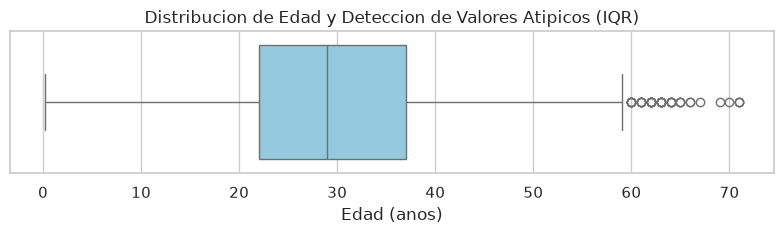

In [ ]:
# Verificacion de registros duplicados
num_duplicados = df.duplicated().sum()
print(f'Total de filas completamente duplicadas: {num_duplicados}')

# Analisis de valores atipicos (outliers) en Age mediante Rango Intercuartilico (IQR)
age_series = df['Age'].dropna()
Q1 = age_series.quantile(0.25)
Q3 = age_series.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_edad = df[(df['Age'] < limite_inferior) | (df['Age'] > limite_superior)]

print(f'Q1 (25%): {Q1:.1f} años | Mediana: {age_series.median():.1f} años | Q3 (75%): {Q3:.1f} años')
print(f'IQR: {IQR:.1f} años | Limite superior teorico: {limite_superior:.1f} años')
print(f'Cantidad de observaciones por encima del limite superior: {len(outliers_edad)} ({len(outliers_edad)/len(df)*100:.2f}%)')
print(f'Edades de los registros atipicos: {sorted(outliers_edad["Age"].unique())}')

# Boxplot ilustrativo de la distribucion de edad
fig, ax = plt.subplots(figsize=(8, 2.5))
sns.boxplot(x=df['Age'], color='skyblue', ax=ax)
ax.set_title('Distribucion de Edad y Deteccion de Valores Atipicos (IQR)')
ax.set_xlabel('Edad (años)')
plt.show()

**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| **Data Leakage (Variables post-evento)** | `Boat [Body]`, `Date_Death`, `URL` | Eliminación definitiva del dataframe de modelado | Son variables que contienen información posterior al rescate o revelan directamente el desenlace; usarlas falsearía el poder predictivo real del modelo. |
| **Identificadores y redundancias** | `Name_ID`, `Name`, `First`, `Last`, `DoB`, `DoB_Clean`, `Year_Birth`, `Age_F_Code`, `Age_F`, `Class`, `Job`, `Price`, `Occupation`, `Ticket`, `Female`, `Male` | Descarte del conjunto de datos | Introducen alta dimensionalidad espuria o duplican la información provista por `Age`, `Sex` y `Class/Dept`. `Price` se descarta además por formato monetario no numérico y nulo para tripulantes. |
| **Valores faltantes sistemáticos (MAR)** | `sibsp`, `parch` (899 filas) | Se conservan las filas; se asignará valor 0 durante el preprocesamiento | Los 899 nulos corresponden con precisión matemática a la tripulación, quienes no tenían registro civil familiar a bordo. Descartar estas filas eliminaría toda la tripulación del estudio. |
| **Valores faltantes aleatorios (MAR/MCAR)** | `Age` (54 filas, $2.45\%$) | Se conservan las filas; se imputará con la mediana de entrenamiento | Representa un porcentaje menor al $3\%$. Aplicar `dropna()` generaría pérdida innecesaria de potencia muestral. La mediana es robusta ante asimetrías. |
| **Valores atipicos en Edad** | `Age` (41 observaciones de 60 a 71 años) | Conservación íntegra de los registros sin truncamiento | Las edades registradas son biológicamente válidas para adultos mayores y oficiales de rango superior (señal real, no error de transcripción). |
| **Registros duplicados** | Ninguno (0 duplicados) | Verificación formal | No se requirió descarte por duplicidad. |

## 5. Análisis exploratorio

*Distribuciones, relaciones y la variable objetivo. Cada gráfica lleva debajo una conclusión escrita.*

## 6. Feature engineering

*Encodings, escalamiento y variables derivadas. Partición train/test antes de ajustar cualquier transformación.*

## 7. Modelo baseline

*Baseline trivial frente al modelo k-NN.*

## 8. Conclusiones y límites

*Respuesta fundamentada y límites del análisis.*

## 9. Bitácora de colaboración con AI

*Documentación de asistencia.*

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?